In [1]:
from google.colab import files
uploaded = files.upload()

Saving Resume.csv to Resume.csv


## **Install Required Libraries**

In [2]:
!pip install pdfminer.six
!pip install spacy
!pip install nltk
!pip install scikit-learn

In [3]:
import nltk
nltk.download('stopwords')

!python -m spacy download en_core_web_sm

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 38.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## **Import Libraries**

In [4]:
import os
import pandas as pd
import numpy as np
import re

from pdfminer.high_level import extract_text

from nltk.corpus import stopwords

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
nlp = spacy.load("en_core_web_sm")

## **Load Resume Dataset**

In [8]:
import os

os.listdir()

['.config', '.ipynb_checkpoints', 'Resume.csv', 'sample_data']

In [9]:
import pandas as pd

df = pd.read_csv("Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## **Check Dataset**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [11]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


## **Clean Resume Text**

In [14]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [15]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Resume"] = df["Resume_str"].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,ID,Resume_str,Resume_html,Category,Cleaned_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


## **Define Skills List**

In [17]:
skills = [
'python','java','c++','machine learning','deep learning','nlp',
'sql','tensorflow','pytorch','excel','communication','management',
'data analysis','tableau','power bi','pandas','numpy','scikit-learn'
]

## **Extract Skills**

In [18]:
def extract_skills(text):

    found_skills = []

    for skill in skills:

        if skill in text:
            found_skills.append(skill)

    return found_skills

df["Skills"] = df["Cleaned_Resume"].apply(extract_skills)

df.head()

,ID,Resume_str,Resume_html,Category,Cleaned_Resume,Skills
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,"[management, data analysis]"
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,"[communication, management]"
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...,"[excel, management]"
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...,"[excel, communication, management]"
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,"[excel, management]"


## **Enter Job Description**

In [19]:
job_description = """
Looking for a Data Scientist skilled in
Python, Machine Learning, SQL, Pandas,
Numpy and Deep Learning
"""

In [20]:
job_description = clean_text(job_description)

## **TF-IDF Vectorization**

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

resume_vectors = vectorizer.fit_transform(df["Cleaned_Resume"])

job_vector = vectorizer.transform([job_description])

## **Calculate Similarity Score**

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(job_vector, resume_vectors)

df["Score"] = similarity_scores[0]

In [37]:
similarity_scores = cosine_similarity(job_vector, resume_vectors)

df["Score"] = similarity_scores[0]

df["Score"] = df["Score"] * 100

## **Create Missing_Skills**

In [38]:
job_skills = extract_skills(job_description)

def skill_gap(candidate_skills):

    missing = list(set(job_skills) - set(candidate_skills))

    return missing

df["Missing_Skills"] = df["Skills"].apply(skill_gap)

## **Rank Candidates**

In [39]:
ranked_candidates = df.sort_values(by="Score", ascending=False)

ranked_candidates.head(10)

,ID,Resume_str,Resume_html,Category,Cleaned_Resume,Skills,Score,Missing_Skills
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering quality technician career overview...,"[python, machine learning, sql, excel, managem...",15.980693,"[deep learning, numpy]"
926,62994611,SOFTWARE DEVELOPER Professi...,"<div class=""MPR skn-cbg1 fontsize fontface vma...",AGRICULTURE,software developer professional summary enthus...,"[python, java, sql, tensorflow, excel, communi...",15.951560,"[deep learning, machine learning, numpy]"
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial s...,"[python, sql, excel, data analysis, tableau, p...",15.856483,"[deep learning, machine learning]"
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,"[python, machine learning, sql, management]",13.410947,"[deep learning, numpy, pandas]"
2291,12777487,ONLINE LEARNING COORDINATOR - PROGRAM...,"<div class=""fontsize fontface vmargins hmargin...",ARTS,online learning coordinator program training s...,[management],13.132855,"[python, sql, deep learning, machine learning,..."
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,"[python, java, machine learning, sql, manageme...",12.256799,"[deep learning, numpy, pandas]"
1142,30863060,CONSULTANT Summary College g...,"<div class=""fontsize fontface vmargins hmargin...",CONSULTANT,consultant summary college graduate interest i...,"[java, sql, excel, communication, management, ...",12.177950,"[python, deep learning, machine learning, pand..."
194,18835363,PROGRAM MANAGER & DESIGNER ...,"<div class=""skn-cbg1 fontsize fontface vmargin...",DESIGNER,program manager designer professional summary ...,[management],11.144870,"[python, sql, deep learning, machine learning,..."
374,36206485,TEACHER Summary An elementar...,"<div class=""fontsize fontface vmargins hmargin...",TEACHER,teacher summary elementary school teacher many...,"[excel, communication, management]",9.630663,"[python, sql, deep learning, machine learning,..."
929,11813872,"VP, PRINCIPAL Summary I am ...","<div class=""RNA skn-cnt4 fontsize fontface vma...",AGRICULTURE,vp principal summary highly skilled growth min...,"[python, java, sql, management, pandas]",9.530848,"[deep learning, machine learning, numpy]"


## **Show Top Candidates**

In [41]:
job_skills = extract_skills(job_description)

def skill_gap(candidate_skills):
    return list(set(job_skills) - set(candidate_skills))

df["Missing_Skills"] = df["Skills"].apply(skill_gap)

ranked_candidates = df.sort_values(by="Score", ascending=False)

top_candidates = ranked_candidates.head(5)

top_candidates[["Category","Skills","Missing_Skills","Score"]]

,Category,Skills,Missing_Skills,Score
1762,ENGINEERING,"[python, machine learning, sql, excel, managem...","[deep learning, numpy]",15.980693
926,AGRICULTURE,"[python, java, sql, tensorflow, excel, communi...","[deep learning, machine learning, numpy]",15.951560
1339,AUTOMOBILE,"[python, sql, excel, data analysis, tableau, p...","[deep learning, machine learning]",15.856483
2153,BANKING,"[python, machine learning, sql, management]","[deep learning, numpy, pandas]",13.410947
2291,ARTS,[management],"[python, sql, deep learning, machine learning,...",13.132855


## **Visualization**

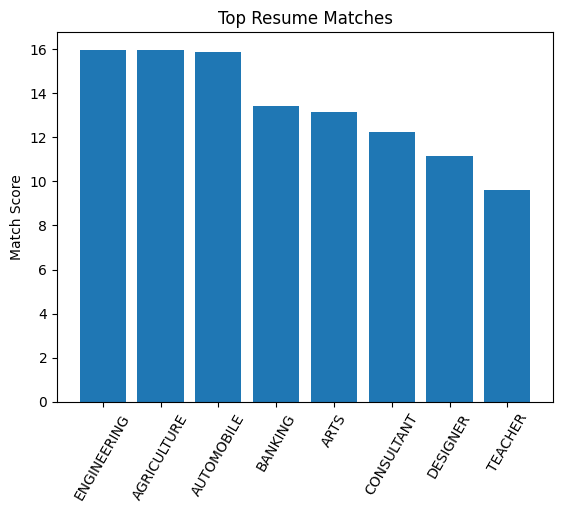

In [42]:
import matplotlib.pyplot as plt

top10 = ranked_candidates.head(10)

plt.figure()

plt.bar(top10["Category"], top10["Score"])

plt.xticks(rotation=60)

plt.title("Top Resume Matches")

plt.ylabel("Match Score")

plt.show()